In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
!pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile

# Define the path to the zipped dataset
ZIP_FILE_PATH = "/content/drive/MyDrive/final_dataset (1).zip"

# Define the directory where you want to extract the dataset
EXTRACT_PATH = "/content/final_dataset_extracted"

# Create the extraction directory if it doesn't exist
if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH)

print(f"Attempting to unzip {ZIP_FILE_PATH} to {EXTRACT_PATH}...")
try:
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction complete!")

    # After extraction, try to find the actual base path within the extracted directory
    # This assumes the zip contains a single top-level folder, which is common.
    # You might need to adjust this if the structure is different.
    extracted_contents = os.listdir(EXTRACT_PATH)
    if len(extracted_contents) == 1 and os.path.isdir(os.path.join(EXTRACT_PATH, extracted_contents[0])):
        # If there's one top-level directory, that's likely the true base path
        # Based on the previous output, it seems to be /content/final_dataset_extracted/content/final_dataset
        BASE_PATH = os.path.join(EXTRACT_PATH, extracted_contents[0], 'final_dataset') # Corrected path
    else:
        # Otherwise, the extraction path itself might be the base, or it's more complex
        BASE_PATH = EXTRACT_PATH # Default to extraction path, user might need to adjust

    print(f"Deduced BASE_PATH after extraction: {BASE_PATH}")

    # --- New Diagnostic Code: List contents of the deduced BASE_PATH ---
    if os.path.exists(BASE_PATH):
        print(f"Contents of deduced BASE_PATH ({BASE_PATH}):")
        for item in os.listdir(BASE_PATH):
            print(f"  - {item}")
    else:
        print(f"Error: Deduced BASE_PATH '{BASE_PATH}' does not exist. Cannot list its contents.")
    # --- End New Diagnostic Code ---

except FileNotFoundError:
    print(f"Error: ZIP file not found at '{ZIP_FILE_PATH}'. Please check the path.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

# --- Diagnostic Code (from original cell, modified to use new BASE_PATH) --- #
if not os.path.exists(BASE_PATH):
    print(f"Error: BASE_PATH '{BASE_PATH}' does not exist after extraction.")
    print("Please check the extracted structure or manually set BASE_PATH.")
    # No need to list MyDrive again, as we just tried to extract
    raise FileNotFoundError(f"BASE_PATH not found after extraction: {BASE_PATH}")
# --- End Diagnostic Code --- #

TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR  = os.path.join(BASE_PATH, "train/labels")  # Corrected: adjust to 'labels' folder

VAL_IMAGE_DIR = os.path.join(BASE_PATH, "val/images")
VAL_MASK_DIR  = os.path.join(BASE_PATH, "val/masks")      # create if missing

TEST_IMAGE_DIR = os.path.join(BASE_PATH, "test/images")
TEST_MASK_DIR  = os.path.join(BASE_PATH, "test/masks")    # optional

# Check contents
print("Checking contents with updated BASE_PATH:")
print("Train images:", len(os.listdir(TRAIN_IMAGE_DIR)))
print("Train masks:", len(os.listdir(TRAIN_MASK_DIR)))
print("Validation images:", len(os.listdir(VAL_IMAGE_DIR)))
if os.path.exists(VAL_MASK_DIR):
    print("Validation masks:", len(os.listdir(VAL_MASK_DIR)))
else:
    print("Validation masks folder does not exist")

Attempting to unzip /content/drive/MyDrive/final_dataset (1).zip to /content/final_dataset_extracted...
Extraction complete!
Deduced BASE_PATH after extraction: /content/final_dataset_extracted/content/final_dataset
Contents of deduced BASE_PATH (/content/final_dataset_extracted/content/final_dataset):
  - test
  - val
  - train
Checking contents with updated BASE_PATH:
Train images: 176
Train masks: 176
Validation images: 36
Validation masks folder does not exist


In [ ]:
import shutil
import random
import os

# Explicitly set BASE_PATH to the correctly extracted location
BASE_PATH = "/content/final_dataset_extracted/content/final_dataset"

# Redefine directory variables based on the correct BASE_PATH
TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR  = os.path.join(BASE_PATH, "train/labels")

VAL_IMAGE_DIR = os.path.join(BASE_PATH, "val/images")
VAL_MASK_DIR  = os.path.join(BASE_PATH, "val/masks")

os.makedirs(VAL_IMAGE_DIR, exist_ok=True)
os.makedirs(VAL_MASK_DIR, exist_ok=True)

TRAIN_IMG_FILES = os.listdir(TRAIN_IMAGE_DIR)
random.seed(42)
VAL_SAMPLE_FILES = random.sample(TRAIN_IMG_FILES, k=int(0.2*len(TRAIN_IMG_FILES)))  # 20% for val

for img_name in VAL_SAMPLE_FILES:
    # Move image
    shutil.move(os.path.join(TRAIN_IMAGE_DIR, img_name),
                os.path.join(VAL_IMAGE_DIR, img_name))
    # Move corresponding mask
    mask_name = img_name.replace('.jpg', '.txt')  # Assuming mask has .txt extension
    src_mask = os.path.join(TRAIN_MASK_DIR, mask_name)
    dst_mask = os.path.join(VAL_MASK_DIR, mask_name)
    if os.path.exists(src_mask):
        shutil.move(src_mask, dst_mask)
    else:
        print(f"Warning: Mask for {img_name} not found at {src_mask}")

print("Validation set created!")
print("Validation images:", len(os.listdir(VAL_IMAGE_DIR)))
print("Validation masks:", len(os.listdir(VAL_MASK_DIR)))

Validation set created!
Validation images: 69
Validation masks: 35


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
import os
import cv2 # Import cv2 for polygon drawing

class SegmentationDataset(Dataset):
    def __init__(self, image_filepaths, mask_filepaths, transform=None, target_size=(256, 256)):
        self.image_filepaths = image_filepaths
        self.mask_filepaths = mask_filepaths
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_filepaths)

    def __getitem__(self, idx):
        img_path = self.image_filepaths[idx]
        mask_path = self.mask_filepaths[idx]

        # Load image
        image = Image.open(img_path).convert("RGB")
        original_img_w, original_img_h = image.size

        # Create empty mask (numpy array)
        mask_np = np.zeros((original_img_h, original_img_w), dtype=np.uint8)

        # Parse the .txt mask file (assuming YOLO segmentation format: class_id x1 y1 x2 y2 ... xn yn)
        try:
            with open(mask_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if not parts:
                        continue

                    # Assuming first part is class_id, rest are normalized polygon coordinates
                    # class_id = int(parts[0]) # If you need class_id, store it. For binary, we just draw.
                    polygon_coords_normalized = list(map(float, parts[1:]))

                    # Convert normalized coords to pixel coords
                    polygon_points = []
                    for i in range(0, len(polygon_coords_normalized), 2):
                        x = int(polygon_coords_normalized[i] * original_img_w)
                        y = int(polygon_coords_normalized[i+1] * original_img_h)
                        polygon_points.append((x, y))

                    if polygon_points:
                        pts = np.array(polygon_points, np.int32)
                        pts = pts.reshape((-1, 1, 2))
                        cv2.fillPoly(mask_np, [pts], 1) # Fill with 1 (foreground)
        except Exception as e:
            print(f"Warning: Could not parse mask file {mask_path}. Error: {e}. Returning empty mask.")
            # If parsing fails, mask_np remains all zeros of original size

        # Resize image and numpy mask to target_size
        image = image.resize(self.target_size)
        mask_pil = Image.fromarray(mask_np).resize(self.target_size, Image.NEAREST)

        # Apply torchvision.transforms.ToTensor() to image and mask
        # transforms.ToTensor() scales image pixels to [0,1]
        image_tensor = transforms.ToTensor()(image)

        # Convert mask to Tensor, scale to [0,1] if it's already 0/1, and ensure float32
        mask_tensor = torch.tensor(np.array(mask_pil), dtype=torch.float32)

        return image_tensor, mask_tensor

In [ ]:
BATCH_SIZE = 4

# Defining BASE_PATH and other directory variables explicitly as they were deleted.
BASE_PATH = "/content/final_dataset_extracted/content/final_dataset"
TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR  = os.path.join(BASE_PATH, "train/labels")
VAL_IMAGE_DIR   = os.path.join(BASE_PATH, "val/images")
VAL_MASK_DIR    = os.path.join(BASE_PATH, "val/masks")
TEST_IMAGE_DIR  = os.path.join(BASE_PATH, "test/images")
TEST_MASK_DIR   = os.path.join(BASE_PATH, "test/masks")

# Re-create matched lists (as they were deleted and needed here)
# --- Fixing Data Mismatch: Training Set ---
train_images_filenames = [f for f in os.listdir(TRAIN_IMAGE_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
train_masks_filenames = [f for f in os.listdir(TRAIN_MASK_DIR) if f.endswith(('.txt', '.png', '.jpeg'))]

matched_train_images = []
matched_train_masks = []

for img_name in train_images_filenames:
    base_name = os.path.splitext(img_name)[0] # Get filename without extension
    mask_name_txt = base_name + '.txt'

    if mask_name_txt in train_masks_filenames:
        matched_train_images.append(os.path.join(TRAIN_IMAGE_DIR, img_name))
        matched_train_masks.append(os.path.join(TRAIN_MASK_DIR, mask_name_txt))

# --- Fixing Data Mismatch: Validation Set ---
val_images_filenames = [f for f in os.listdir(VAL_IMAGE_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
val_masks_filenames = [f for f in os.listdir(VAL_MASK_DIR) if f.endswith(('.txt', '.png', '.jpeg'))]

matched_val_images = []
matched_val_masks = []

for img_name in val_images_filenames:
    base_name = os.path.splitext(img_name)[0]
    mask_name_txt = base_name + '.txt'

    if mask_name_txt in val_masks_filenames:
        matched_val_images.append(os.path.join(VAL_IMAGE_DIR, img_name))
        matched_val_masks.append(os.path.join(VAL_MASK_DIR, mask_name_txt))


# Training dataset
train_dataset = SegmentationDataset(matched_train_images, matched_train_masks)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Validation dataset
val_dataset = SegmentationDataset(matched_val_images, matched_val_masks)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)


Train samples: 141
Val samples: 35
Image batch shape: torch.Size([4, 3, 256, 256])
Mask batch shape: torch.Size([4, 256, 256])


In [ ]:
import torch.nn as nn
import torchvision.models.segmentation as segmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DeepLabV3
model = segmentation.deeplabv3_resnet50(pretrained=True)
# Adjust final classifier for 2 classes (background + site)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=(1,1))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device)

        if len(masks.shape) == 4:
            masks = masks.squeeze(1)
        masks = masks.long()

        outputs = model(images)['out']
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.5311
Epoch 2/5, Loss: 0.4956
Epoch 3/5, Loss: 0.4652
Epoch 4/5, Loss: 0.4669
Epoch 5/5, Loss: 0.4492


In [ ]:
model.eval()
val_loss = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks  = masks.to(device)

        if len(masks.shape) == 4:
            masks = masks.squeeze(1)
        masks = masks.long()

        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        val_loss += loss.item()

print(f"Validation Loss: {val_loss/len(val_loader):.4f}")

Validation Loss: 1.0886


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/final dataset"
# Create the directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "deeplabv3_segmentation.pth"))
print("Segmentation model saved to Google Drive!")

Segmentation model saved to Google Drive!


In [ ]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17851 (delta 28), reused 9 (delta 7), pack-reused 17809 (from 3)
Receiving objects: 100% (17851/17851), 17.00 MiB | 14.60 MiB/s, done.
Resolving deltas: 100% (12171/12171), done.


In [ ]:
%cd yolov5

/content/yolov5


In [ ]:
!ls

benchmarks.py	 data	     LICENSE	     README.zh-CN.md   tutorial.ipynb
CITATION.cff	 detect.py   models	     requirements.txt  utils
classify	 export.py   pyproject.toml  segment	       val.py
CONTRIBUTING.md  hubconf.py  README.md	     train.py


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
!ls /content/drive/MyDrive

 chettinad.v1i.yolov8.zip  'final dataset'	   'final_dataset (1).zip'
'Colab Notebooks'	   'final dataset(1).zip'


In [ ]:
!ls "/content/drive/MyDrive/final dataset"

deeplabv3_segmentation.pth


In [ ]:
!ls "$TRAIN_IMAGE_DIR"

img10_jpg.rf.20dd64e2f26f108132b5713ac1fafca2.jpg
img10_jpg.rf.7c40a27cc98ea88833da16ce4057ca04.jpg
img10_jpg.rf.b91bd066e2ed6c9b2360713979836a26.jpg
img11_jpg.rf.1ad535e14b2def5aecb4d8f6a7dbfb3c.jpg
img11_jpg.rf.46fefaf16dc5f95fe9e407846295d04e.jpg
img11_jpg.rf.f30313dfa5ac389a337dde9081b967b0.jpg
img12_jpg.rf.3d77feb9a9cd2f71c01f754068e6903c.jpg
img12_jpg.rf.ccb25b5fea1003ac5d9ab1ad20b808ed.jpg
img14_jpg.rf.a86c15fb7a8df643531be470811b0029.jpg
img15_jpg.rf.47cf0eef21d87d24d9143917b971ae1a.jpg
img15_jpg.rf.bf7bfcf7a4098a5dca040c946343a9be.jpg
img17_jpg.rf.b869635a0c45578bd71e6a80a0b703e5.jpg
img18_jpg.rf.4c37ff373c85ba66e321df155f410654.jpg
img18_jpg.rf.56f399db11a5985acf0920913aa79e6d.jpg
img18_jpg.rf.a9133cb9709235a1f849448da2618fa7.jpg
img19_jpg.rf.f18f32709502fc985e828ba1dc6783b7.jpg
img1_jpg.rf.697e231aeae40e31647d43f53cece29e.jpg
img1_jpg.rf.7286fb55901056d971d3da87b4019183.jpg
img20_jpg.rf.3b57cd9caa144a335ce37da27ef74895.jpg
img20_jpg.rf.ee0e7b024486b81dfb6b28c13ce44c30.jpg
im

In [ ]:
%%writefile dataset.yaml
path: /content/final_dataset_extracted/content/final_dataset

train: train/images
val: val/images
test: test/images

names:
  0: buildings
  1: roadline
  2: vegetation
  3: water
  4: other
  5: unknown_5 # Added to resolve IndexError: index 6 out of bounds
  6: unknown_6 # Added to resolve IndexError: index 6 out of bounds

Writing dataset.yaml


In [ ]:
from ultralytics import YOLO

# Ensure we are in the yolov5 directory if not already
%cd /content/yolov5

model = YOLO("yolov8n.pt")

model.train(
    data="dataset.yaml",
    epochs=150, # Increased epochs for better training
    imgsz=640,
    batch=16,
    name="train_7_classes" # Give a new name to the training run to avoid overwriting previous runs
)

/content/yolov5
Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_7_classes2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cdc2c4fa600>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     


image 1/36 /content/final_dataset_extracted/content/final_dataset/test/images/img12_jpg.rf.3ad1a53865aeec70fc9a6b92a9a23401.jpg: 640x640 12 buildingss, 8 waters, 13 others, 6.6ms
image 2/36 /content/final_dataset_extracted/content/final_dataset/test/images/img13_jpg.rf.b31153bd39fd6e8332490b10a5ea7422.jpg: 640x640 10 buildingss, 9 others, 7.5ms
image 3/36 /content/final_dataset_extracted/content/final_dataset/test/images/img14_jpg.rf.c0d34f986d4a038fe55223571f180c9d.jpg: 640x640 4 buildingss, 1 water, 13 others, 6.7ms
image 4/36 /content/final_dataset_extracted/content/final_dataset/test/images/img16_jpg.rf.6c8097d7fc3454d99aa3cc7983b1f6d7.jpg: 640x640 7 buildingss, 2 waters, 6 others, 1 unknown_6, 8.0ms
image 5/36 /content/final_dataset_extracted/content/final_dataset/test/images/img17_jpg.rf.52e33708ce428164ea746743a38fcc0b.jpg: 640x640 7 buildingss, 2 waters, 13 others, 6.6ms
image 6/36 /content/final_dataset_extracted/content/final_dataset/test/images/img1_jpg.rf.7e1a5ff33358f6997

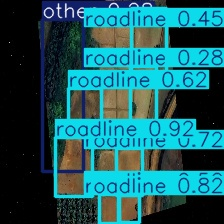

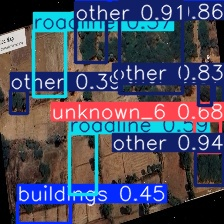

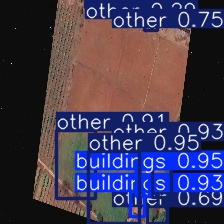

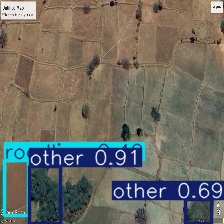

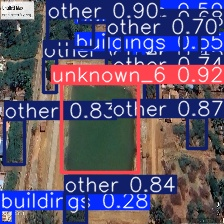

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display

# Load model
model_path = "runs/detect/train_7_classes/weights/best.pt"  # Corrected path
model = YOLO(model_path)

# Run prediction
results = model.predict(
    source="/content/final_dataset_extracted/content/final_dataset/test/images",
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True
)

# \u2705 Correct folder
predict_runs_dir = "runs/detect"

# Find latest predict folder
predict_dirs = [d for d in os.listdir(predict_runs_dir) if "predict" in d]
predict_dirs.sort(key=lambda x: os.path.getmtime(os.path.join(predict_runs_dir, x)), reverse=True)

if predict_dirs:
    latest_predict_run = os.path.join(predict_runs_dir, predict_dirs[0])
    print(f"Latest prediction results saved to: {latest_predict_run}")

    # Display images
    output_images = [f for f in os.listdir(latest_predict_run) if f.endswith(('.jpg', '.png', '.jpeg'))]

    for img in output_images[:5]:  # show first 5 images
        display(Image(filename=os.path.join(latest_predict_run, img)))
else:
    print("No prediction folders found.")

In [ ]:
import os

for root, dirs, files in os.walk("runs"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))

runs/detect/train_7_classes2/weights/best.pt
runs/detect/train_7_classes/weights/best.pt


In [ ]:
# After the previous training run (named 'train_7_classes') completes,
# the best model will likely be saved in 'runs/detect/train_7_classes/weights/best.pt'.
# You might need to verify the exact path by checking the 'runs/detect/' directory
# if the name 'train_7_classes' was already taken or modified by Ultralytics.

!python val.py \
--weights runs/detect/train_7_classes/weights/best.pt \
--data dataset.yaml \
--img 640

val: data=dataset.yaml, weights=['runs/detect/train_7_classes/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /content/final_dataset_extracted/content/final_dataset/val/labels... 36 images, 33 backgrounds, 0 corrupt: 100% 69/69 [00:00<00:00, 1080.92it/s]
val: New cache created: /content/final_dataset_extracted/content/final_dataset/val/labels.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95:   0% 0/3 [00:00<?, ?it/s]WARNING ⚠️ NMS time limit 2.100s exceeded
                 Class     Images  Instances       

In [ ]:
from google.colab import files
files.download('runs/detect/train_7_classes/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('runs/detect/train_7_classes/results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>